# NWB to Brainset Conversion Tutorial

This tutorial shows how to use `Nwb2Brainset` to convert NWB files into
[temporaldata](https://github.com/neuro-galaxy/temporaldata) objects compatible
with [torch_brain](https://github.com/neuro-galaxy/torch_brain) / brainsets.

The converter:
- Discovers all convertible objects in an NWB file (units, intervals, time series)
- Maps each to the appropriate `temporaldata` type (`ArrayDict`, `IrregularTimeSeries`, `RegularTimeSeries`, `Interval`)
- Supports lazy loading (data stays on disk until accessed)
- Supports `include`/`exclude` filtering
- Is extensible via subclassing or per-key converter overrides

## 1. Open an NWB file and create the converter

In [1]:
from pynwb import read_nwb
from load_nwb import Nwb2Brainset

fpath = "/Users/luiztauffer/Downloads/nwb_files/sub-CSHL045_ses-46794e05-3f6a-4d35-afb3-9165091a5a74_desc-processed_behavior+ecephys.nwb"
nwbfile = read_nwb(fpath)

converter = Nwb2Brainset(nwbfile, lazy_loading=True)

/opt/miniconda3/envs/torch_brain/lib/python3.12/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)


## 2. Inspect available objects

`check()` prints all convertible objects found in the NWB file, organized by type.
The keys shown (e.g. `units`, `acquisition__raw_running_wheel_rotation`) are the
same keys you pass to `include`/`exclude` when loading.

In [2]:
converter.check()

 NWB File Contents

[Spiking Data]
  units  (nwbfile.units)
    n_units  : 1,324
    n_spikes : 38,524,829
    columns  : unit_name, spike_count, isi_violations_ratio, spike_amplitudes_uV, kilosort2_label, noise_cutoff, missed_spikes_estimate, distance_from_probe_tip_um  + 18 more

[TimeIntervals]
  trials  (nwbfile.trials)
    n_rows   : 807
    columns  : start_time, stop_time, quiescence_period, gabor_stimulus_onset_time, auditory_cue_time, wheel_movement_onset_time, choice_registration_time, feedback_time  + 9 more
  intervals__epochs  (nwbfile.intervals['epochs'])
    n_rows   : 2
    columns  : start_time, stop_time, protocol_type, epoch_description
  processing__passive_protocol__gabor_table  (nwbfile.processing['passive_protocol']['gabor_table'])
    n_rows   : 179
    columns  : start_time, stop_time, position, contrast, phase
  processing__passive_protocol__passive_intervals  (nwbfile.processing['passive_protocol']['passive_intervals'])
    n_rows   : 2
    columns  : start_t

## 3. Load everything

`load()` converts all discovered objects and wraps them in a `temporaldata.Data` container.
With `lazy_loading=True`, large data arrays stay as HDF5 references until accessed.

In [3]:
d = converter.load()
d

Data(
units=ArrayDict(
  id=[1324],
  nwb_id=[1324],
  unit_name=[1324],
  spike_count=[1324],
  isi_violations_ratio=[1324],
  kilosort2_label=[1324],
  noise_cutoff=[1324],
  missed_spikes_estimate=[1324],
  distance_from_probe_tip_um=[1324],
  presence_ratio=[1324],
  sliding_rp_violation=[1324],
  presence_ratio_std=[1324],
  cluster_uuid=[1324],
  spike_amplitude_std_dB=[1324],
  peak_to_trough_duration_ms=[1324],
  firing_rate=[1324],
  cumulative_drift_um_per_hour=[1324],
  min_spike_amplitude_uV=[1324],
  max_spike_amplitude_uV=[1324],
  rp_violation=[1324],
  median_spike_amplitude_uV=[1324],
  probe_name=[1324],
  ibl_quality_score=[1324]
),
spikes=IrregularTimeSeries(
  timestamps=[38524829],
  unit_index=[38524829]
),
trials=Interval(
  start=[807],
  end=[807],
  quiescence_period=[807],
  gabor_stimulus_onset_time=[807],
  auditory_cue_time=[807],
  wheel_movement_onset_time=[807],
  choice_registration_time=[807],
  feedback_time=[807],
  gabor_stimulus_offset_time=[807]

### Save to HDF5

After loading, call `save()` to write the `Data` object to an HDF5 file. This file can then be loaded by torch_brain.

In [4]:
converter.save("session.h5")

## 4. Selective loading with `include` / `exclude`

Use `include` to load only specific objects, or `exclude` to skip some.
The keys match exactly what `check()` prints.

In [5]:
# Only load units and trials
d_subset = converter.load(include=["units", "trials"])
d_subset

Data(
units=ArrayDict(
  id=[1324],
  nwb_id=[1324],
  unit_name=[1324],
  spike_count=[1324],
  isi_violations_ratio=[1324],
  kilosort2_label=[1324],
  noise_cutoff=[1324],
  missed_spikes_estimate=[1324],
  distance_from_probe_tip_um=[1324],
  presence_ratio=[1324],
  sliding_rp_violation=[1324],
  presence_ratio_std=[1324],
  cluster_uuid=[1324],
  spike_amplitude_std_dB=[1324],
  peak_to_trough_duration_ms=[1324],
  firing_rate=[1324],
  cumulative_drift_um_per_hour=[1324],
  min_spike_amplitude_uV=[1324],
  max_spike_amplitude_uV=[1324],
  rp_violation=[1324],
  median_spike_amplitude_uV=[1324],
  probe_name=[1324],
  ibl_quality_score=[1324]
),
spikes=IrregularTimeSeries(
  timestamps=[38524829],
  unit_index=[38524829]
),
trials=Interval(
  start=[807],
  end=[807],
  quiescence_period=[807],
  gabor_stimulus_onset_time=[807],
  auditory_cue_time=[807],
  wheel_movement_onset_time=[807],
  choice_registration_time=[807],
  feedback_time=[807],
  gabor_stimulus_offset_time=[807]

In [6]:
# Load everything except units/spikes
d_no_spikes = converter.load(exclude=["units"])
d_no_spikes

Data(
trials=Interval(
  start=[807],
  end=[807],
  quiescence_period=[807],
  gabor_stimulus_onset_time=[807],
  auditory_cue_time=[807],
  wheel_movement_onset_time=[807],
  choice_registration_time=[807],
  feedback_time=[807],
  gabor_stimulus_offset_time=[807],
  gabor_stimulus_contrast=[807],
  gabor_stimulus_side=[807],
  mouse_wheel_choice=[807],
  is_mouse_rewarded=[807],
  reward_volume_uL=[807],
  probability_left=[807],
  block_type=[807],
  block_index=[807]
),
intervals__epochs=Interval(
  start=[2],
  end=[2],
  protocol_type=[2],
  epoch_description=[2]
),
processing__motion_energy__LeftCameraMotionEnergy=LazyIrregularTimeSeries(
  timestamps=[319703],
  data=<HDF5 dataset "data": shape (319703,), type "<f8">
),
processing__motion_energy__RightCameraMotionEnergy=LazyIrregularTimeSeries(
  timestamps=[800879],
  data=<HDF5 dataset "data": shape (800879,), type "<f8">
),
processing__passive_protocol__gabor_table=Interval(
  start=[179],
  end=[179],
  position=[179],
  c

## 5. Opening from file path (with automatic cleanup)

`from_file` opens the NWB file and returns a converter that can be used as a context manager.
The file is automatically closed when the `with` block exits.

In [7]:
fpath = "/Users/luiztauffer/Downloads/nwb_files/sub-CSHL045_ses-46794e05-3f6a-4d35-afb3-9165091a5a74_desc-processed_behavior+ecephys.nwb"

with Nwb2Brainset.from_file(fpath) as conv:
    conv.check()
    d = conv.load(include=["units", "trials"])

/opt/miniconda3/envs/torch_brain/lib/python3.12/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)


 NWB File Contents

[Spiking Data]
  units  (nwbfile.units)
    n_units  : 1,324
    n_spikes : 38,524,829
    columns  : unit_name, spike_count, isi_violations_ratio, spike_amplitudes_uV, kilosort2_label, noise_cutoff, missed_spikes_estimate, distance_from_probe_tip_um  + 18 more

[TimeIntervals]
  trials  (nwbfile.trials)
    n_rows   : 807
    columns  : start_time, stop_time, quiescence_period, gabor_stimulus_onset_time, auditory_cue_time, wheel_movement_onset_time, choice_registration_time, feedback_time  + 9 more
  intervals__epochs  (nwbfile.intervals['epochs'])
    n_rows   : 2
    columns  : start_time, stop_time, protocol_type, epoch_description
  processing__passive_protocol__gabor_table  (nwbfile.processing['passive_protocol']['gabor_table'])
    n_rows   : 179
    columns  : start_time, stop_time, position, contrast, phase
  processing__passive_protocol__passive_intervals  (nwbfile.processing['passive_protocol']['passive_intervals'])
    n_rows   : 2
    columns  : start_t

## 6. Custom converters

You can override how specific objects are converted in two ways:

### Per-key override (ad-hoc)
Set `converters_by_name` to assign a custom function to a specific key:

```python
def my_custom_converter(obj):
    # custom conversion logic
    ...

converter.converters_by_name["processing__wheel__WheelPositionSmoothed"] = my_custom_converter
d = converter.load()
```

### Subclassing (reusable)
Override `converters_by_type` to handle new NWB types, or override
individual `convert_*` methods:

```python
class MyConverter(Nwb2Brainset):
    converters_by_name = {
        "processing__wheel__WheelPositionSmoothed": "convert_wheel_position",
    }

    def convert_wheel_position(self, obj):
        # custom logic for this specific object
        ...
```

## 7. Creating a custom Dataset for torch_brain

Once your data is saved as h5, the next step is creating a `Dataset` subclass that
torch_brain's samplers and dataloaders can consume.

The base `torch_brain.dataset.Dataset` class:
- Discovers all `*.h5` files in a directory
- Loads each as a `temporaldata.Data` object via `Data.from_hdf5()`
- Returns time-sliced samples via `__getitem__(DatasetIndex)`
- Exposes `get_sampling_intervals()` to tell samplers **where** to sample from

It is with the `get_sampling_intervals()` method that we define train/valid/test splits.

### Example: IBL Choice task

For this dataset, we want to sample 1-second windows aligned to the gabor stimulus onset in each trial. We split the trials into train/valid/test (70/15/15).

In [8]:
import numpy as np
from typing import Optional, Literal
from temporaldata import Interval
from torch_brain.dataset import Dataset


class IBLChoiceDataset(Dataset):
    """Dataset for IBL Choice sessions with trial-aligned sampling intervals.

    For each trial, we create a 1-second window starting at gabor_stimulus_onset_time.
    Trials are split into train/valid/test at construction time.
    """

    def __init__(
        self,
        dataset_dir,
        split_ratios=(0.7, 0.15, 0.15),
        random_seed=42,
        **kwargs,
    ):
        super().__init__(dataset_dir, **kwargs)
        self.split_ratios = split_ratios
        self.random_seed = random_seed

        # Precompute splits for each recording
        self._split_intervals = {}
        for rid in self.recording_ids:
            data = self.get_recording(rid)
            trials = data.trials

            # Task-aligned windows: gabor onset → gabor onset + 1s
            stimulus_intervals = Interval(
                start=np.array(trials.gabor_stimulus_onset_time),
                end=np.array(trials.gabor_stimulus_onset_time) + 1.0,
            )

            # Split trials into train/valid/test
            train, valid, test = stimulus_intervals.split(
                list(split_ratios), shuffle=True, random_seed=random_seed
            )
            self._split_intervals[rid] = {
                "train": train,
                "valid": valid,
                "test": test,
            }

    def get_sampling_intervals(
        self, split: Optional[Literal["train", "valid", "test"]] = None
    ):
        """Return sampling intervals, optionally filtered by split.

        When split is None, returns the full domain of each recording.
        When split is "train"/"valid"/"test", returns only the trial-aligned
        intervals for that split.
        """
        if split is None:
            return {rid: self.get_recording(rid).domain for rid in self.recording_ids}
        return {rid: self._split_intervals[rid][split] for rid in self.recording_ids}

### Instantiate the dataset

Point it at the directory containing the h5 file(s) saved earlier.
The dataset auto-discovers all `*.h5` files and precomputes the trial splits.

In [9]:
# Point to the directory where session.h5 was saved
dataset = IBLChoiceDataset("./")

print(f"Recordings: {dataset.recording_ids}")
print(f"Train intervals: {dataset.get_sampling_intervals('train')}")
print(f"Valid intervals: {dataset.get_sampling_intervals('valid')}")
print(f"Test intervals:  {dataset.get_sampling_intervals('test')}")

Recordings: ['session']
Train intervals: {'session': Interval(
  start=[565],
  end=[565]
)}
Valid intervals: {'session': Interval(
  start=[121],
  end=[121]
)}
Test intervals:  {'session': Interval(
  start=[121],
  end=[121]
)}


### Use with torch_brain's sampler

The sampler generates `DatasetIndex` objects (recording_id, start, end) that the
dataset uses to return time-sliced `Data` samples. Each sample contains only the
spikes, trials, and other data within that 1-second window.

In [12]:
import torch
from torch_brain.data.sampler import RandomFixedWindowSampler

# Create a sampler that draws 1-second windows from the train split
train_sampler = RandomFixedWindowSampler(
    sampling_intervals=dataset.get_sampling_intervals("train"),
    window_length=1.0,
    generator=torch.Generator().manual_seed(42),
)

print(f"Number of train samples: {len(train_sampler)}")

# Peek at a single sample
sample_index = next(iter(train_sampler))
print(f"\nSample index: {sample_index}")

sample = dataset[sample_index]

Number of train samples: 565

Sample index: DatasetIndex(recording_id='session', start=np.float64(890.2574), end=np.float64(891.2574), _namespace='')


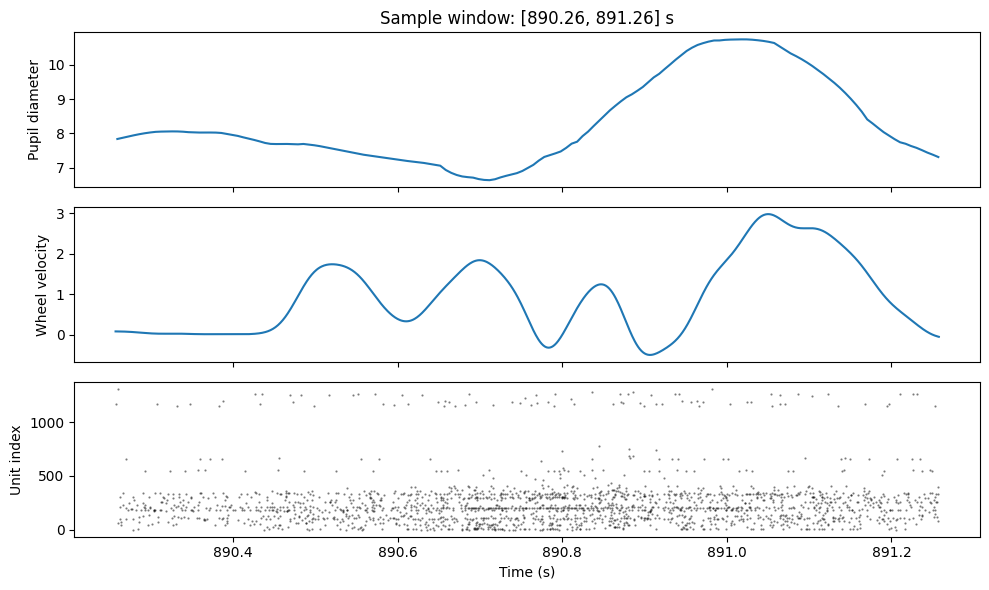

In [13]:
import matplotlib.pyplot as plt

t0 = sample._absolute_start

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

# Pupil diameter
pupil = sample.processing__pupil__RightPupilDiameterSmoothed
axes[0].plot(pupil.timestamps + t0, pupil.data)
axes[0].set_ylabel("Pupil diameter")
axes[0].set_title(f"Sample window: [{sample_index.start:.2f}, {sample_index.end:.2f}] s")

# Wheel velocity
wheel = sample.processing__wheel__WheelVelocitySmoothed
t = np.linspace(wheel.domain.start[0] + t0, wheel.domain.end[0] + t0, len(wheel.data))
axes[1].plot(t, wheel.data)
axes[1].set_ylabel("Wheel velocity")

# Spikes raster
spikes = sample.spikes
axes[2].scatter(spikes.timestamps + t0, spikes.unit_index, s=0.3, alpha=0.5, color="k")
axes[2].set_ylabel("Unit index")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()
